In [41]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [42]:
data = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')

In [43]:
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [44]:
data = np.array(data)

In [45]:
m, n = data.shape
np.random.shuffle(data)
data_dev = data[0:1000].T
Y_dev = data_dev[0]
X_dev = data_dev[1:n] / 255.0
data_train = data[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n] / 255.0

In [46]:
def init_params():
    # He initialization: scales by sqrt(2/fan_in), ideal for ReLU
    W1 = np.random.randn(10, 784) * np.sqrt(2 / 784)
    b1 = np.zeros((10, 1))          # Biases start at zero
    W2 = np.random.randn(10, 10) * np.sqrt(2 / 10)
    b2 = np.zeros((10, 1))
    return W1, b1, W2, b2

def ReLU(Z):
    return np.maximum(Z, 0)

def softmax(Z):
    # Subtracting np.max(Z) prevents "Exploding Gradients" (Numerical Stability)
    expZ = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return expZ / np.sum(expZ, axis=0, keepdims=True)

def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def ReLU_deriv(Z):
    return Z > 0

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    return one_hot_Y.T

def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    m = Y.size
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2, axis=1, keepdims=True)
    dZ1 = W2.T.dot(dZ2) * ReLU_deriv(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1, axis=1, keepdims=True)
    return dW1, db1, dW2, db2
def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1    
    W2 = W2 - alpha * dW2  
    b2 = b2 - alpha * db2    
    return W1, b1, W2, b2

In [47]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        
        # ADD THIS DEBUG BLOCK
        if i % 10 == 0:
            print(f"dW1 mean abs: {np.mean(np.abs(dW1)):.6f}")
            print(f"dW2 mean abs: {np.mean(np.abs(dW2)):.6f}")
            print(f"A1 zero%: {np.mean(A1 == 0)*100:.1f}%")
            print(f"Z1 range: [{Z1.min():.2f}, {Z1.max():.2f}]")
        
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 10 == 0:
            predictions = get_predictions(A2)
            print(f"Iter {i} accuracy: {get_accuracy(predictions, Y):.4f}")
    return W1, b1, W2, b2

In [48]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 0.10, 500)

dW1 mean abs: 0.002936
dW2 mean abs: 0.004532
A1 zero%: 64.2%
Z1 range: [-2.19, 2.31]
[2 2 2 ... 8 2 2] [3 8 3 ... 6 1 1]
Iter 0 accuracy: 0.0866
dW1 mean abs: 0.003382
dW2 mean abs: 0.011363
A1 zero%: 44.9%
Z1 range: [-2.50, 2.86]
[9 2 2 ... 9 1 1] [3 8 3 ... 6 1 1]
Iter 10 accuracy: 0.2906
dW1 mean abs: 0.002763
dW2 mean abs: 0.020281
A1 zero%: 37.3%
Z1 range: [-2.62, 3.83]
[2 1 2 ... 4 1 1] [3 8 3 ... 6 1 1]
Iter 20 accuracy: 0.4761
dW1 mean abs: 0.002391
dW2 mean abs: 0.019966
A1 zero%: 33.9%
Z1 range: [-2.62, 5.24]
[2 2 2 ... 4 1 1] [3 8 3 ... 6 1 1]
Iter 30 accuracy: 0.6194
dW1 mean abs: 0.002061
dW2 mean abs: 0.015981
A1 zero%: 31.1%
Z1 range: [-2.70, 6.75]
[3 2 3 ... 6 1 1] [3 8 3 ... 6 1 1]
Iter 40 accuracy: 0.7060
dW1 mean abs: 0.001763
dW2 mean abs: 0.013705
A1 zero%: 29.2%
Z1 range: [-2.98, 8.03]
[3 2 3 ... 6 1 1] [3 8 3 ... 6 1 1]
Iter 50 accuracy: 0.7501
dW1 mean abs: 0.001525
dW2 mean abs: 0.012162
A1 zero%: 28.0%
Z1 range: [-3.28, 9.02]
[3 2 3 ... 6 1 1] [3 8 3 ... 6 1 

In [49]:


def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()



Prediction:  [3]
Label:  3


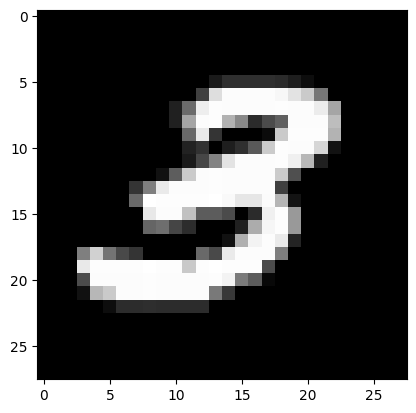

Prediction:  [8]
Label:  8


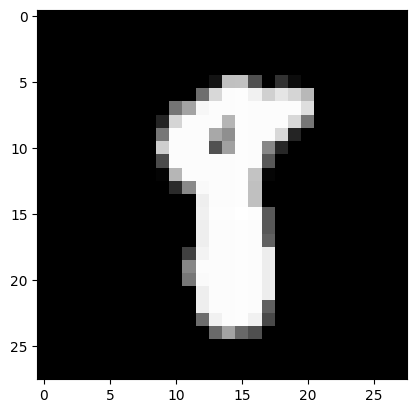

Prediction:  [3]
Label:  3


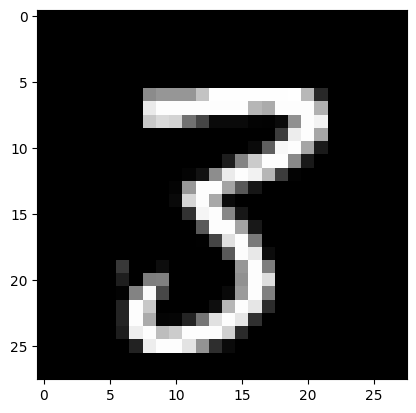

Prediction:  [1]
Label:  1


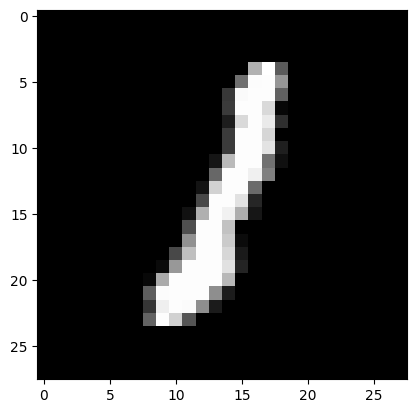

In [52]:
import matplotlib.pyplot as plt

test_prediction(0, W1, b1, W2, b2)
test_prediction(1, W1, b1, W2, b2)
test_prediction(2, W1, b1, W2, b2)
test_prediction(3, W1, b1, W2, b2)

